In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import bernoulli, binom, poisson, lognorm, powerlaw, boxcox, norm
import statsmodels.api as sm

In [28]:
df = pd.read_csv("spread_locator_dataset.csv",index_col=0)
    

In [29]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])


In [30]:
df['transaction_occurred'] = df['transaction_status'].apply(lambda x: 1 if x == 'Success' else 0)

p_hat = df['transaction_occurred'].mean()
print("Bernoulli Probability (p):", p_hat)

# Binomial: Weekly transaction count
weekly_counts = df.groupby(df['transaction_date'].dt.to_period('W'))['transaction_occurred'].sum()
n = weekly_counts.max()
p = weekly_counts.mean() / n

print("Binomial n:", n, "p:", p)

Bernoulli Probability (p): 0.44545454545454544
Binomial n: 23 p: 0.7101449275362318


Poisson Lambda: 20.258064516129032


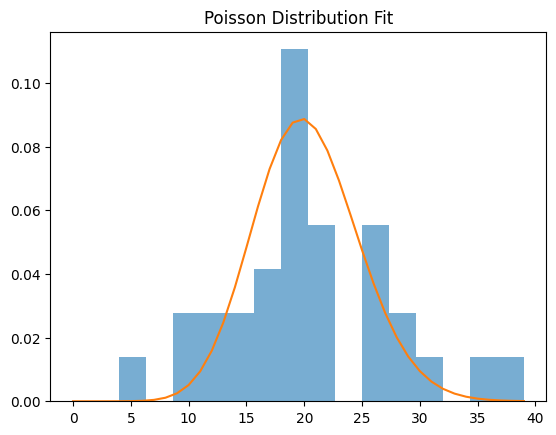

In [31]:
daily_counts = df.groupby('transaction_date')['transaction_count'].sum()
lambda_hat = daily_counts.mean()

print("Poisson Lambda:", lambda_hat)

# Plot Poisson Fit
x = np.arange(0, daily_counts.max()+1)
plt.figure()
plt.hist(daily_counts, bins=15, density=True, alpha=0.6)
plt.plot(x, poisson.pmf(x, lambda_hat))
plt.title("Poisson Distribution Fit")
plt.show()


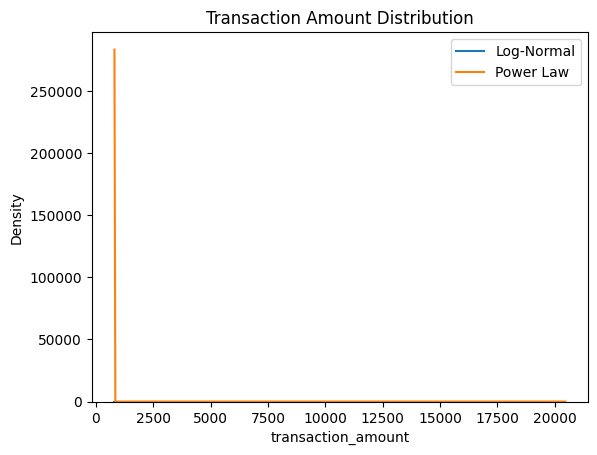

In [33]:
amounts = df['transaction_amount']

shape, loc, scale = lognorm.fit(amounts, floc=0)

a, loc_p, scale_p = powerlaw.fit(amounts)


plt.figure()
sns.histplot(amounts, bins=30, stat="density")
x_vals = np.linspace(amounts.min(), amounts.max(), 500)
plt.plot(x_vals, lognorm.pdf(x_vals, shape, loc, scale), label="Log-Normal")
plt.plot(x_vals, powerlaw.pdf(x_vals, a, loc_p, scale_p), label="Power Law")
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()


<Figure size 640x480 with 0 Axes>

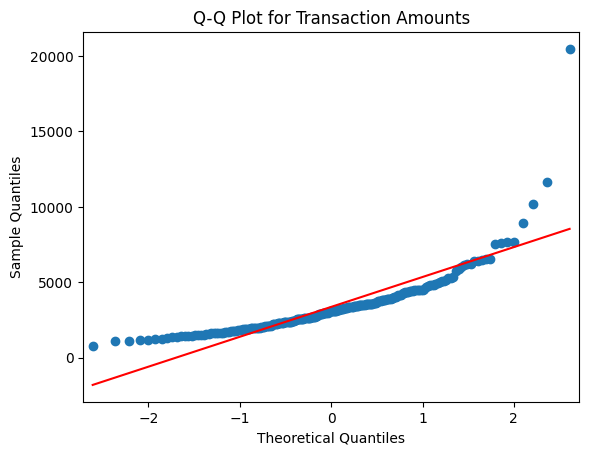

In [34]:
plt.figure()
sm.qqplot(amounts, line='s')
plt.title("Q-Q Plot for Transaction Amounts")
plt.show()

Box-Cox Lambda: -0.18123612911845818


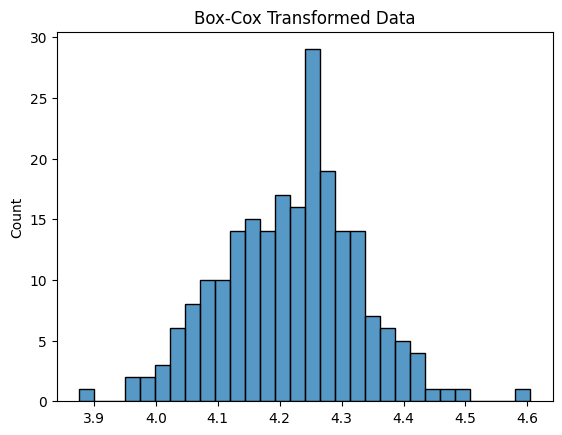

In [35]:
amounts_positive = amounts + 1 
boxcox_transformed, lambda_bc = boxcox(amounts_positive)

print("Box-Cox Lambda:", lambda_bc)

plt.figure()
sns.histplot(boxcox_transformed, bins=30)
plt.title("Box-Cox Transformed Data")
plt.show()


In [36]:
mean_amt = amounts.mean()
std_amt = amounts.std()

z_5000 = (5000 - mean_amt) / std_amt
prob_exceed_5000 = 1 - norm.cdf(z_5000)

print("Z-score for ₹5000:", z_5000)
print("Probability Amount > ₹5000:", prob_exceed_5000)

Z-score for ₹5000: 0.8232880785671723
Probability Amount > ₹5000: 0.20517209567554384
